# Bilateral Trading on the WSCC 9-Bus: a Double-Auction Model

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

The companion notebook **101** clears a single nodal market by solving a
security-constrained economic dispatch (SCED). SCED solves an optimization problem to find the
least-cost feasible dispatch and provides the locational prices from its duals. In bilateral markets generators and loads trade
**pairwise**, each protecting its own position, and the schedule that emerges is an
**equilibrium of offers**, not the solution of an optimization.

This notebook builds a **numerical model of bilateral trading** to produce the **day-ahead pre-schedule** for private unit commitment.
The model is a **repeated discriminatory double auction** drawn from the
agent-based-market literature (Nicolaisen-Petrov-Tesfatsion 2001; Rustichini-
Satterthwaite-Williams 1994; Gode-Sunder 1993) with a **forward risk premium**
(Bessembinder-Lemmon 2002), because committing ahead of an uncertain spot price is a
forward contract and the parties price risk into their offers.

In theory a sufficiently competitive bilateral market will result in the same prices as a centrally cleared market. Three configurable parameters in the notebook reflect the drivers of equilibrium prices from competitive levels --
the **number of parties** (liquidity), the **risk attitudes**, and the **rebalancing risk**. Bilateral markets on a transmission network have no single competitive price and the pre-schedule is feasible only **contract by contract**; superposed on the grid it
can **overload** a line, so it is then subject to **real-time balancing** that
redispatches it to a network-feasible state. The three issues are covered in their own sections of the notebook.



## 0. Setup and the scenario

In [1]:
#@title Run me first: Colab setup (installs packages, fetches the helper modules)
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py",
              "wscc9_figures.py", "atc.py", "bilateral.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")

Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib, collections
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)
logging.getLogger('ieee9_network').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

import seams_engine, nodal_plot, wscc9_model, footprints, atc, bilateral, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, atc, bilateral, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, atc, bilateral as bl, wscc9_figures as figs
from wscc9_model import build_network, shift_factors, BUS_COLORS, COORDS, RING_ORDER, CENTER_BUS
from nodal_plot import plot_network_topology, plot_combined_letter

pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='',
                         float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'
try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

### Configuration of tunable parameters

For the double-auction mechanisms, demand is provided an administrative budget that it will not offer above. How close to competitive the bilateral market gets is also driven by tunable parameters for the
number of parties (liquidity), the price-risk distribution width, and the two risk
attitudes. Because a bilateral double auction is **not** a deterministic optimization,
the offers are random draws, so a **seed** fixes one realization for the worked
examples (later sections average over many).

In [3]:
# =========================  CONFIGURATION -- EDIT HERE  =========================
RATINGS       = {'line_4': 60.0, 'line_2': 90.0}  # line limits (MW): tightened so prices separate
VOLL          = 200.0   # the load's BUDGET: the value ceiling it never bids above ($/MWh)
FIRMNESS      = 0.7     # shapes the demand value curve (how fast value falls toward the margin)
N_PARTIES     = 4       # blocks per resource -- the number of competing parties (liquidity)
PRICE_RISK    = 20.0    # sigma of each party's perceived spot-price distribution ($/MWh)
GEN_APPETITE  = 1.0     # sellers' appetite for the upside tail (ask reach above cost)
LOAD_AVERSION = 1.5     # loads' aversion to the upside tail (forward bid premium)
K_SPLIT       = 0.5     # who keeps the spread: 0.5 = midpoint; 0 = buyer lifts the ask; 1 = seller takes the bid
ROUNDS        = 12      # bargaining rounds before the book is declared done
SEED          = 3       # the draw of one interval's offers
# ===============================================================================
pt = shift_factors(build_network(line_ratings=RATINGS))
suppliers = [bl.Supplier(g, s['bus'], s['cost'], s['p_nom'])
             for g, s in wm.DEFAULT_GEN_FLEET.items()]
lcs = bl.calibrate_load_centers(pt, voll=VOLL, firmness=FIRMNESS)

def belief(price_risk=PRICE_RISK, gen_appetite=GEN_APPETITE, load_aversion=LOAD_AVERSION):
    return bl.Belief(price_risk=price_risk, gen_appetite=gen_appetite, load_aversion=load_aversion)

def clear(belief_=None, N=N_PARTIES, seed=SEED, rounds=ROUNDS, network='rights', k=K_SPLIT):
    return bl.double_auction_clear(pt, suppliers, lcs, belief=belief_ or belief(),
                                   rng=np.random.default_rng(seed), thickness=N,
                                   rounds=rounds, network=network, k=k)

print('fixed marginal costs:', {s.bus: s.cost for s in suppliers})
print('expected (competitive) prices p_comp:', {k: round(lc.p_comp, 1) for k, lc in lcs.items()})
print('forecast demand (MW):', {k: lc.d_nom for k, lc in lcs.items()},
      '| total', sum(lc.d_nom for lc in lcs.values()))

fixed marginal costs:

{'1': 50.0, '2': 35.0, '3': 20.0}

expected (competitive) prices p_comp:

{'5': 55.6, '7': 30.6, '9': 44.8}

forecast demand (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

| total

315.0

In [4]:
# --- figure helpers (each ends in plt.show()) ---
def metrics(r):
    # the two clean summaries of a clearing: price DISPERSION (how scattered the cleared
    # prices are -- the liquidity/spread measure) and the PREMIUM over competitive.
    px = np.array([t['price'] for t in r.trades]); w = np.array([t['qty'] for t in r.trades])
    avg = np.average(px, weights=w)
    disp = float(np.sqrt(np.average((px - avg) ** 2, weights=w)))
    prem = float(np.nanmean([v for v in r.premium.values() if v == v]))
    return disp, prem

def clearing_figure(da, title):
    # One box per cleared trade: its bottom is the seller's ASK, its top the buyer's BID, and
    # the black dot is the MIDPOINT they settle at -- always inside the box. The box height is
    # that trade's bid-ask spread; trades are ordered left-to-right by their clearing price.
    T = sorted([t for t in da.trades if t['qty'] > 1e-9], key=lambda t: t['price'])
    qty = np.array([t['qty'] for t in T]); x = np.cumsum(qty) - qty / 2.0
    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    for t, xi, w in zip(T, x, qty):
        ax.add_patch(plt.Rectangle((xi - w / 2, t['ask']), w, max(0.05, t['bid'] - t['ask']),
                                   facecolor='#A9DFBF', edgecolor='none', alpha=0.6))
    ax.scatter(x, [t['s_cost'] for t in T], marker='x', s=22, color='#D98880', zorder=3,
               label='seller cost (true floor)')
    ax.scatter(x, [t['ask'] for t in T], marker='_', s=55, color='#C0392B', zorder=4, label='ask (sealed seller offer)')
    ax.scatter(x, [t['bid'] for t in T], marker='_', s=55, color='#2471A3', zorder=4, label='bid (sealed buyer offer)')
    ax.scatter(x, [t['price'] for t in T], color='black', s=13, zorder=5, label='midpoint (the cleared price)')
    ax.set_xlabel('cumulative cleared quantity (MW), ordered by clearing price')
    ax.set_ylabel('price  (USD/MWh)'); ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(alpha=0.3); plt.show()

def rounds_figure(da, title):
    av, bv, vol, w = (collections.defaultdict(float) for _ in range(4))
    for t in da.trades:
        av[t['round']] += t['ask'] * t['qty']; bv[t['round']] += t['bid'] * t['qty']
        vol[t['round']] += t['qty']; w[t['round']] += t['qty']
    rs = sorted(vol)
    fig, ax = plt.subplots(figsize=(7.2, 4.3)); ax2 = ax.twinx()
    ax2.bar(rs, [vol[r] for r in rs], color='#D5DBDB', alpha=0.8, zorder=0)
    ax.plot(rs, [av[r] / w[r] for r in rs], marker='v', color='#C0392B', label='avg accepted ask')
    ax.plot(rs, [bv[r] / w[r] for r in rs], marker='^', color='#2471A3', label='avg accepted bid')
    ax.set_xlabel('bargaining round'); ax.set_ylabel('offer price (USD/MWh)')
    ax2.set_ylabel('MW cleared this round', color='#7F8C8D')
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
    ax.set_title(title); ax.legend(fontsize=8, loc='center right'); ax.grid(alpha=0.3); plt.show()

def lever_figure(df, xcol, xlabel, title):
    fig, ax = plt.subplots(figsize=(7.0, 4.2)); ax2 = ax.twinx()
    ax.plot(df[xcol], df['dispersion'], marker='o', color='#7D3C98')
    ax2.plot(df[xcol], df['premium'], marker='s', color='#C0392B')
    ax.set_xlabel(xlabel); ax.set_ylabel('price dispersion (USD/MWh)', color='#7D3C98')
    ax2.set_ylabel('premium over competitive (USD/MWh)', color='#C0392B')
    ax.set_title(title); ax.grid(alpha=0.3); plt.show()

def bilateral_dispatch_figure(da, suppliers, title, monitored='all', pt_=None, line_ratings=None):
    pt_ = pt if pt_ is None else pt_
    line_ratings = RATINGS if line_ratings is None else line_ratings
    # GENERATORS: the solid bar is the FIXED marginal cost; the dotted staircase over it is
    # the band of cleared (sale) prices its blocks fetched. LOADS: the receive-bar is
    # segmented by the prices it PAID. Chords are the actual bilateral gen->load contracts.
    sup_rows, dem_seg, agg, num, den = {}, {}, {}, {}, {}
    for t in da.trades:
        sup_rows.setdefault(t['sbus'], {})
        skey = (round(t['s_cost']), round(t['price']))
        sup_rows[t['sbus']][skey] = sup_rows[t['sbus']].get(skey, 0.0) + t['qty']
        dem_seg.setdefault(t['center'], {})
        dem_seg[t['center']][round(t['price'])] = dem_seg[t['center']].get(round(t['price']), 0.0) + t['qty']
        agg[(t['sbus'], t['center'])] = agg.get((t['sbus'], t['center']), 0.0) + t['qty']
        for b in (t['sbus'], t['center']):
            num[b] = num.get(b, 0.0) + t['price'] * t['qty']; den[b] = den.get(b, 0.0) + t['qty']
    cap_by_bus, base_cost_by_bus = {}, {}
    for s in suppliers:
        cap_by_bus[s.bus] = cap_by_bus.get(s.bus, 0.0) + s.p_nom
        base_cost_by_bus.setdefault(s.bus, s.cost)
    supply_by_bus, cleared_price_line = {}, {}
    for b, rows in sup_rows.items():
        blocks = []
        for ((c, p), mw) in sorted(rows.items(), key=lambda kv: (kv[0][1], kv[0][0])):
            uid = f'{b}.{len(blocks)}'
            blocks.append({'unit_id': uid, 'price': float(c), 'volume': mw,
                           'accepted_volume': mw, 'capacity': mw})
            cleared_price_line[uid] = float(p)
        supply_by_bus[b] = blocks
    for b, cap in cap_by_bus.items():
        disp = sum(blk['accepted_volume'] for blk in supply_by_bus.get(b, []))
        idle = cap - disp
        if idle > 0.5:
            idle_cost = (sum(blk['price'] * blk['accepted_volume'] for blk in supply_by_bus.get(b, []))
                         / disp) if disp > 0.5 else base_cost_by_bus[b]
            blocks = supply_by_bus.setdefault(b, [])
            blocks.append({'unit_id': f'{b}.idle{len(blocks)}', 'price': float(idle_cost),
                           'volume': round(idle, 1), 'accepted_volume': 0.0, 'capacity': round(idle, 1)})
    demand_by_bus = {c: round(v, 1) for c, v in da.cleared.items() if v > 0.5}
    demand_segments = {c: [{'mw': mw, 'price': float(p)} for p, mw in sorted(seg.items())]
                       for c, seg in dem_seg.items()}
    flows = [(s, c, round(mw, 1)) for (s, c), mw in agg.items() if mw > 0.5]
    bus_lmps = {b: num[b] / den[b] for b in num if den[b] > 0}
    awards = da.awards
    net_mw = {}
    for a in awards:
        net_mw[a.source] = net_mw.get(a.source, 0.0) + a.mw
        net_mw[a.sink] = net_mw.get(a.sink, 0.0) - a.mw
    plot_combined_letter(
        build_network(line_ratings=line_ratings), supply_by_bus, demand_by_bus,
        bus_colors=BUS_COLORS, bus_coords=COORDS, flows=flows, bus_lmps=bus_lmps, bus_net_mw=net_mw,
        gen_marginal_costs=cleared_price_line, lmp_line=False,
        gen_bid_labels=False, gen_cost_labels=True, block_mw_unit=False,
        line_flows=atc.flow_dict(pt_, awards),
        constrained_lines=set(atc.overloaded_lines(pt_, awards, monitored)),
        demand_segments=demand_segments, all_buses=RING_ORDER,
        sector_order=RING_ORDER, center_bus=CENTER_BUS,
        title_left='Network -- physical (PTDF) flow of the bilateral schedule',
        title_right='Bilateral dispatch -- gen cost bar + cleared-price staircase, load price bands',
        suptitle=title)
    plt.show()

print('helpers ready')

helpers ready

## 1. The numerical model of bilateral trading

Bilateral trading is, generally, **private and pairwise**: a generator and a load negotiate a
contract without a public order book or a central price, each guarding its own reservation
price, and the deal closes somewhere between what the seller would accept and what the
buyer would pay. We approximate that with a **sealed-bid (call) $k=\tfrac12$ double auction** (Chatterjee-Samuelson 1983;
Satterthwaite-Williams 1989; the clearinghouse auction of Nicolaisen-Petrov-Tesfatsion
2001). It has two features:
offers are **sealed** (committed without seeing the counterparty's), so there is no central
price discovery; and a matched pair settles at the **midpoint** of its bid and ask, the
even split of the gains a private negotiation would reach. Each pair sets its own price (a
*discriminatory* auction), and because the offers are strategic and noisy most pairs do
**not** overlap at first, so the parties **bargain over rounds** -- an unmatched seller
lowers its ask, an unmatched buyer raises its bid -- until the must-serve load has procured
its full volume.

**Nomenclature.** Sets are script capitals; an element is the matching lower-case letter.

| Symbol | Code | Definition |
|---|---|---|
| $\mathcal S,\ \mathcal B$ | `suppliers`, `lcs` | the sets of seller blocks and buyer blocks in the book; $i\in\mathcal S$, $j\in\mathcal B$ |
| $N$ | `N_PARTIES` | the number of blocks each resource is split into -- the party count |
| $c_i,\ \sigma_i$ | `Supplier.cost`, `PRICE_RISK` | seller $i$'s **fixed** marginal cost and its perceived price-risk |
| $v_j,\ p^{c}_j$ | `VOLL`, `lc.p_comp` | buyer $j$'s **budget** (the value ceiling it never bids above) and expected price (the competitive $p^{comp}$) |
| $\alpha,\ \gamma$ | `GEN_APPETITE`, `LOAD_AVERSION` | the seller **appetite** and load **aversion** for risk |
| $r$ | `ROUNDS` | the bargaining round, $r=0,1,\dots$, up to the cap |
| $\rho,\ \delta,\ \kappa$ | `reach0`, `concede`, `climb` | the seller's opening **reach** above cost, its per-round **concession**, and the buyer's per-round **climb** -- fixed constants that set the bargaining speed |
| $\varepsilon$ | `rng` / `SEED` | an independent **standard-normal draw**, $\varepsilon\sim\mathcal N(0,1)$ -- the per-offer noise, scaled by $1/\sqrt N$ |
| $a^r_i,\ b^r_j$ | `t['ask']`, `t['bid']` | the ask and bid posted in round $r$ |
| $A_{n\to k}$ | `da.awards` | the awarded delivery from generator bus $n$ to load center $k$ (a transmission right) |

**Offers (round $r$).** Each still-unfilled block draws an offer from its perceived
spot-price distribution. A **seller** reaches above its cost for margin at first and
concedes back toward that cost the longer it goes unsold:

$$ a^r_i=\max\!\Big(c_i,\; c_i+\alpha\,\sigma_i\,(\rho-\delta r)^{+}+\tfrac{\sigma_i}{\sqrt N}\,\varepsilon\Big). \tag{1} $$

*In words.* The ask is the seller's **fixed cost plus a markup**, with the outer floor keeping
it from ever falling below that cost -- a seller will not offer to lose money. The markup is
the seller's **appetite for upside** scaled by **how uncertain the spot price is**, and it
**shrinks each round**: the seller reaches high for margin in the opening round and gives
ground toward cost the longer it stays unsold. The last term is a small **random spread**
across the resource's blocks that **tightens as the resource is split among more parties** --
a deeper market is a quieter one.

A **buyer** starts at the price it expects generation to cost and climbs toward its budget the
longer it goes unserved:

$$ b^r_j=\min\!\Big(v_j,\; p^{c}_j+\gamma\,\sigma\,\kappa r+\tfrac{\sigma}{\sqrt N}\,\varepsilon\Big). \tag{2} $$

*In words.* The bid is the **expected cost of generation plus a premium**, with the outer cap
keeping it from ever bidding more than the load is worth -- the budget it will not exceed (the
budget constraint of Gode-Sunder). The premium is the buyer's **aversion to going unserved**
scaled by **the same spot-price uncertainty**, and it **grows each round**: the buyer pays up
for confident delivery, more so the longer it stays unmatched. The same **random spread** rides
on top and **fades as more parties** join.

Together the seller's markup and the buyer's premium are the **two-sided forward premium** of
Bessembinder-Lemmon: both ends price the risk of committing ahead of an uncertain spot price,
so the cleared price settles **above the competitive level** by that premium.

**Matching and price (each round).** Sort the asks ascending and the bids descending, then
pair the highest bid with the lowest ask. A pair trades **only if their offers overlap** --
the bid is at least the ask -- for the smaller of the two quantities and whatever the
**transmission right** $n\to k$ still allows. The pair's outcome is then one of **two cases** --
clear at the **midpoint** of the bid and ask, or no trade at all:

$$ p_{ij}=\begin{cases}\tfrac12\,(b^r_j+a^r_i), & b^r_j\ge a^r_i\ \ (\text{the offers overlap}),\\[4pt] \text{no trade}, & b^r_j<a^r_i. \end{cases} \tag{3} $$

*In words.* A deal is struck **only where the buyer's bid is at least the seller's ask** -- the
bid-ask **overlap** -- and that test runs before any price is set. Where it holds, the two
**split the difference** and clear at the midpoint; where the highest remaining bid is still
below the lowest remaining ask, **no pair clears this round** and the unmatched blocks carry to
the next, the seller conceding and the buyer climbing until they cross.

**Sealed-bid double auction midpoint simplification.** This is the classic $k=\tfrac12$ double auction
(Chatterjee-Samuelson 1983; Satterthwaite-Williams 1989). It is **sealed-bid**: within a
round each party commits its offer *without seeing the others'*, so a matched pair cannot
haggle -- the clearinghouse simply splits their gap at the midpoint. Crucially the ask and
bid are **shaded reservations, not the cost and value**: the seller asks *above* its cost
$c_i$ (it asks for more), the buyer bids *below* its value $v_j$ (it offers to pay less),
and a trade happens only once the bid has crossed *above* the ask. The midpoint then sits
inside that gap, so the seller clears **above its ask** and the buyer pays **below its bid**
-- both beat their own number. *Why doesn't the buyer just lift the seller's ask and pay it?*
Because it never saw the ask; it had already committed its bid. A buyer that shades down to
just above the expected ask pays less, but shade too far and the ask lands *above* the bid
and there is **no trade at all** -- that tension is exactly why the auction is **not
incentive-compatible** and why a bid-ask spread (hence a premium) survives.

**Close and premium.** Carry unfilled blocks to round $r+1$ (sellers conceding, buyers
climbing) until the load's full volume clears. There is **no single price**: the load
pays the volume-weighted midpoint, and the **premium** it pays over the competitive level
is $\;\bar p_k-p^{comp}_k$, the bid-ask spread plus the forward risk premium. It is not
least-cost -- it is the equilibrium of the offers.

> **Modeling choice.** Bilateral power trading is conducted as pairwise private transactions or a *continuous*
> double auction. A brokered transaction or an exchange like ICE is closer to a continuous orderbook/continuous double auction, where standing bids and offers
> are visible and a trader *lifts* an offer or *hits* a bid. The numerical model used in this notebook is the closely related
> *call* (sealed-bid, batch) double auction instead. The **continuous** and **call** auctions are the two canonical double-auction
> institutions (Friedman & Rust 1993), and
> both converge to the competitive equilibrium as the market deepens (Gode-Sunder 1993;
> Rustichini-Satterthwaite-Williams 1994). The periodic call market is no less efficient
> than a continuous one when immediacy is not at a premium
> (Wah, Hurd & Wellman 2016). It is also the standard choice for agent-based electricity markets
> (Nicolaisen-Petrov-Tesfatsion 2001; Tesfatsion's ACE framework).
>
> **Call (sealed-bid batch) double auctions are tractable for our illustrative model.** A continuous book resolves its
> offers *one trade at a time, as traders arrive*, so the outcome is **path-dependent**
> (it depends on who acts when) and each trader's best move is a **dynamic strategy**. The strategy considers when
> to post, when to lift, how to revise as the book evolves. As a result the continuous orderbook problem has no closed form. Instead, an illustrative model needs an arbitrary timing protocol and a Monte Carlo over *event sequences*. The call
> auction commits every offer **at once** and clears them with one deterministic rule, so for
> a given draw of offers the outcome is **determined**. The call double auction has one offer per trader, a clean crossing,
> and the only randomness left to average over is the price-risk draws themselves. The risk
> distributions and the double-blind are fully kept; only the *sequential* resolution is
> dropped. The one visible difference is the price rule: a continuous
> book hands the spread to whoever is *resting* (the taker pays the maker's quote), whereas the
> midpoint splits it evenly. We make that split the lever $k$ (`K_SPLIT`): $k=\tfrac12$ is the
> midpoint, $k\to 0$ recovers "the buyer lifts the ask", $k\to 1$ "the seller takes the bid".

## 2. A first clearing

Run the auction once with the configured levers. The must-serve load procures its **full
forecast**. The first figure shows the **bargaining**: each round the accepted **asks rise**
and accepted **bids fall** as the two sides concede toward one another, and the MW left to
trade taper off -- the back-and-forth converging. The second shows the cleared book **one
trade at a time**: each green box runs from a seller's **ask** (bottom red tick) to a buyer's
**bid** (top blue tick), and the black dot is the **midpoint** they settle at -- always inside
the box, since a pair only trades when the bid is at or above the ask. The faint **x** below
each box is the seller's **true cost**: the ask sits *above* it, so the red tick is the
seller's marked-up *offer*, not its floor (and the buyer's value, the budget `VOLL`, sits far
above the top of the chart, so each blue bid is shaded well below it). The boxes are ordered by
clearing price, so the rising dots are the dispersed prices of a discriminatory auction, not
one clearing price.

procured 315 of 315 MW over 4 rounds

,forecast (MW),procured (MW),competitive p_comp,avg price paid,premium $/MWh
5,90.0,90.0,55.6,49.4,-6.2
7,100.0,100.0,30.6,48.7,18.0
9,125.0,125.0,44.8,51.3,6.5


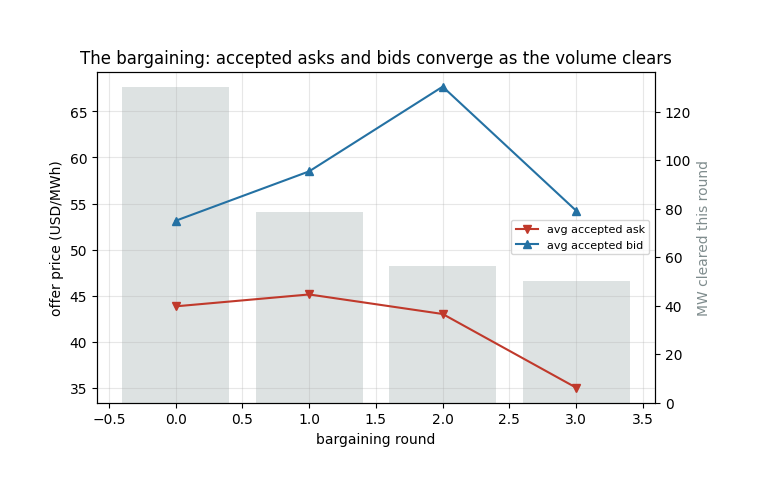

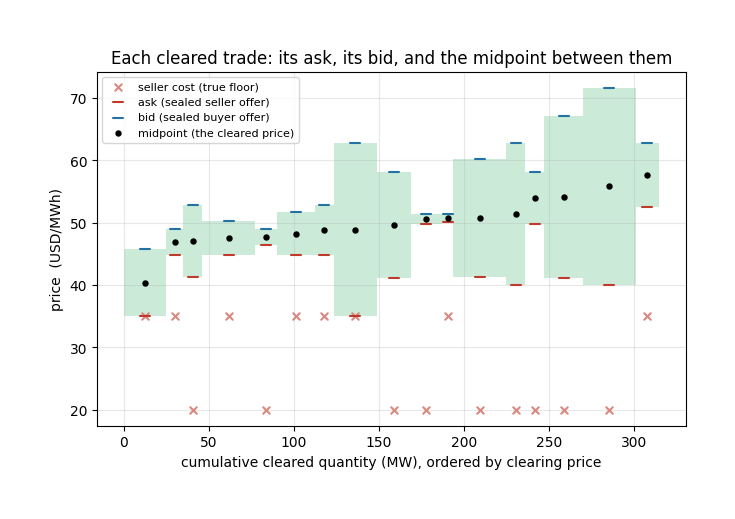

In [5]:
da = clear()
served, fc = sum(da.cleared.values()), sum(da.forecast.values())
print(f'procured {served:.0f} of {fc:.0f} MW over {max(t["round"] for t in da.trades)+1} rounds')
summ = pd.DataFrame({
    'forecast (MW)':       {k: round(da.forecast[k], 0) for k in da.forecast},
    'procured (MW)':       {k: round(da.cleared[k], 0) for k in da.cleared},
    'competitive p_comp':  {k: round(lcs[k].p_comp, 1) for k in da.cleared},
    'avg price paid':      {k: round(da.price[k], 1) for k in da.cleared},
    'premium $/MWh':       {k: round(da.premium[k], 1) for k in da.cleared}})
display(summ)
rounds_figure(da, 'The bargaining: accepted asks and bids converge as the volume clears')
clearing_figure(da, 'Each cleared trade: its ask, its bid, and the midpoint between them')

The same network-plus-dispatch composite from 101 carries over, read for a bilateral
book. There is **no single nodal price**: each generator's solid bar is its **fixed
marginal cost**, the dotted staircase over it the **cleared prices** its blocks fetched
(the gap is the spread it captured); each load's bar is **segmented by the prices it
paid**; the chords are the **actual bilateral contracts**. The left panel is the
**physical** (PTDF) flow of that schedule, nodes labelled by net injection -- the overload
it creates is what Section 5 must balance.

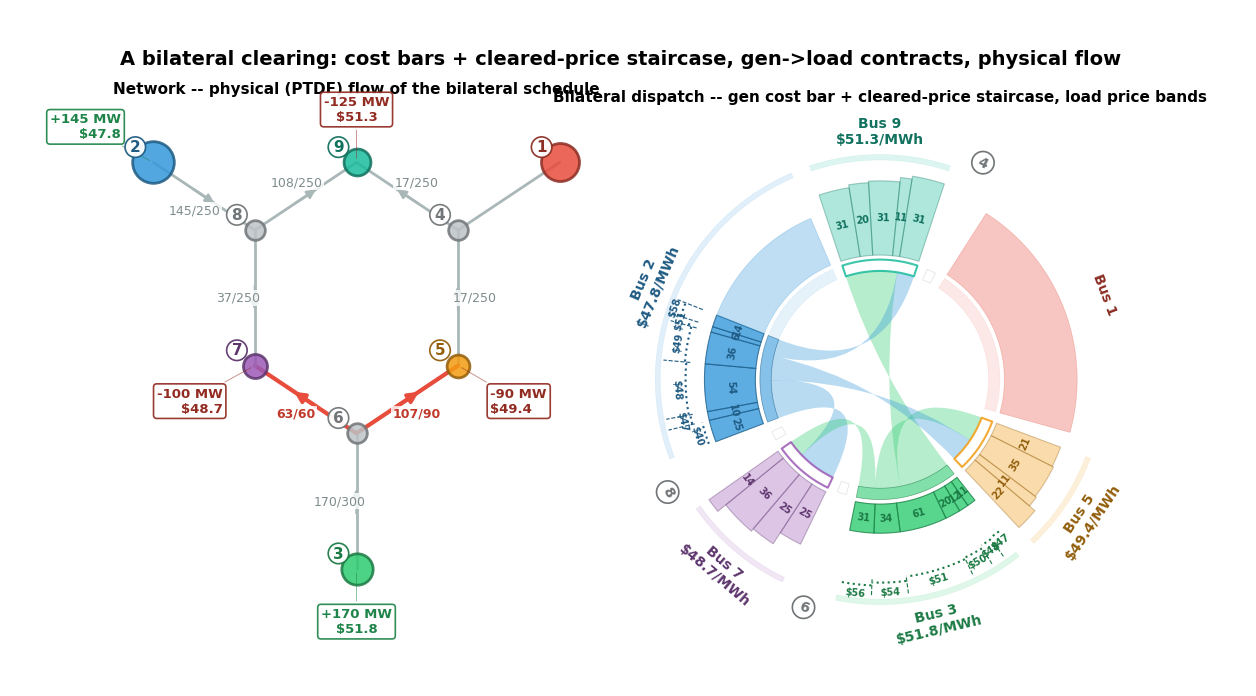

In [6]:
bilateral_dispatch_figure(da, suppliers,
    'A bilateral clearing: cost bars + cleared-price staircase, gen->load contracts, physical flow')

**Who keeps the spread? the price-split `k`.** The same cleared book, settled under the
three conventions: at `k=0` each pair clears at the **seller's ask** (the buyer "lifts the
offer", a continuous-book taker), so the load pays least and sellers keep no spread; at `k=1`
it clears at the **buyer's bid** (the seller "takes the bid"), so the load pays most; the
midpoint `k=0.5` splits the spread evenly. The allocation -- who serves whom -- is unchanged;
`k` only moves money between the counterparties.

In [7]:
rows = []
for kk in (0.0, 0.5, 1.0):
    r = clear(k=kk)
    rows.append({'k': kk,
                 'avg premium $/MWh': round(np.nanmean([v for v in r.premium.values() if v == v]), 1),
                 'seller rent $/h': round(sum(r.seller_profit.values())),
                 'buyer surplus $/h': round(sum(r.buyer_surplus.values()))})
display(pd.DataFrame(rows).set_index('k'))

,avg premium $/MWh,seller rent $/h,buyer surplus $/h
k,,,
0.0,-1.0,4946,49579
0.5,6.1,7251,47274
1.0,13.3,9556,44969


## 3. Lever: the number of parties (liquidity)

The first force is **liquidity**. With few parties the book is thin: offers are dispersed,
the bid-ask spread is wide, and the bargaining takes more rounds. Splitting the same
resources into **more, smaller parties** (`N_PARTIES`) deepens the book -- by the
$1/\sqrt N$ term in (1)-(2) the dispersion shrinks, the spread tightens, and the cleared price
settles toward the underlying risk-adjusted level. (This is the convergence result of
Rustichini-Satterthwaite-Williams: strategic mis-statement, hence the spread, falls like
$O(1/\sqrt N)$.) The **premium does not vanish** -- it is a forward risk premium, a
preference, not a friction -- but the market becomes orderly.

,price dispersion $/MWh,premium $/MWh
N_parties,,
1,9.6,8.7
2,6.1,6.9
4,4.2,7.0
8,2.8,7.8
16,1.9,8.2
32,1.9,8.5


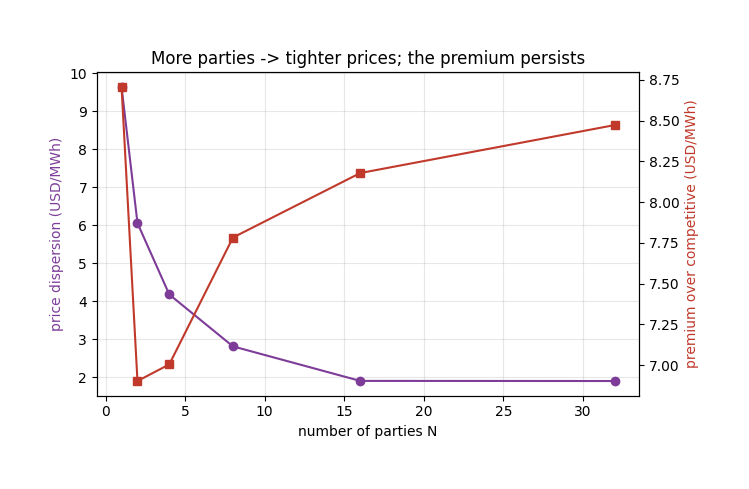

In [8]:
rows = []                          # average over 20 draws so the trend is not draw-noise
for N in (1, 2, 4, 8, 16, 32):
    ms = [metrics(clear(N=N, seed=s)) for s in range(20)]
    rows.append({'N_parties': N, 'dispersion': np.mean([m[0] for m in ms]),
                 'premium': np.mean([m[1] for m in ms])})
liq = pd.DataFrame(rows)
display(liq.assign(**{'price dispersion $/MWh': liq['dispersion'].round(1),
                      'premium $/MWh': liq['premium'].round(1)})
           [['N_parties', 'price dispersion $/MWh', 'premium $/MWh']].set_index('N_parties'))
lever_figure(liq, 'N_parties', 'number of parties N',
             'More parties -> tighter prices; the premium persists')

The two clearings below make the liquidity effect concrete: a **thin** book of one
party per resource clears at scattered prices (a wide spread), while a **deep** book of
sixteen clears at prices bunched near the risk-adjusted level -- the same dispatch, a far
more orderly market.

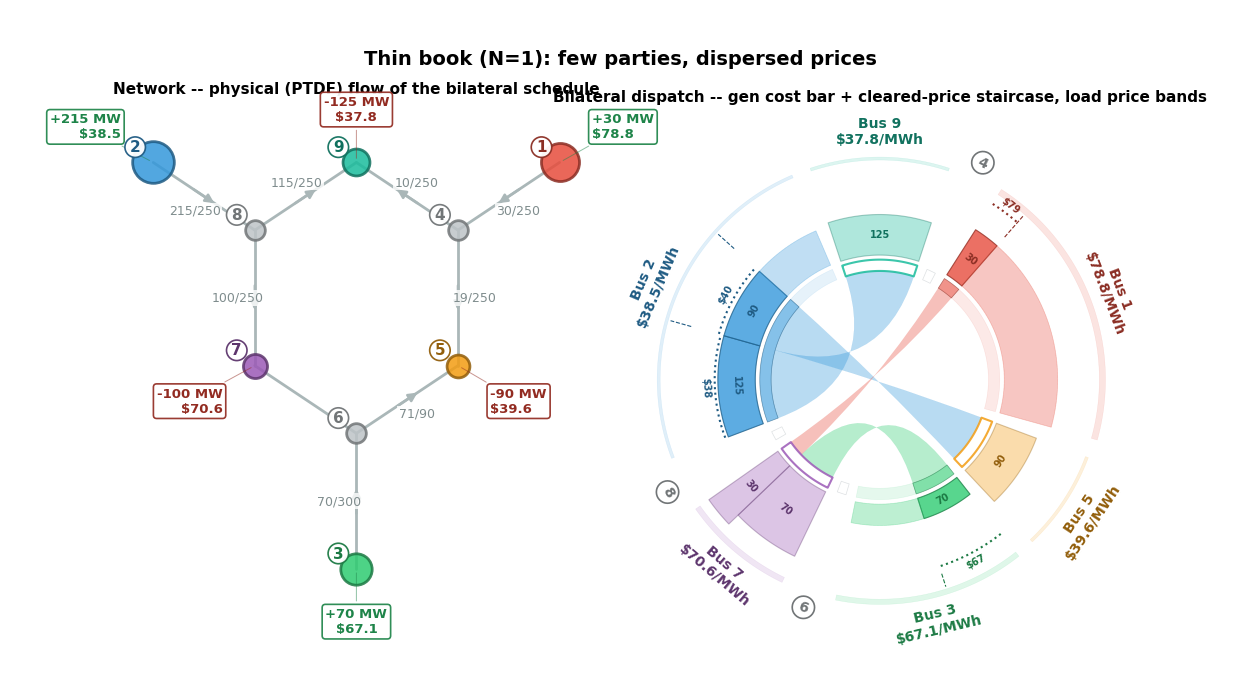

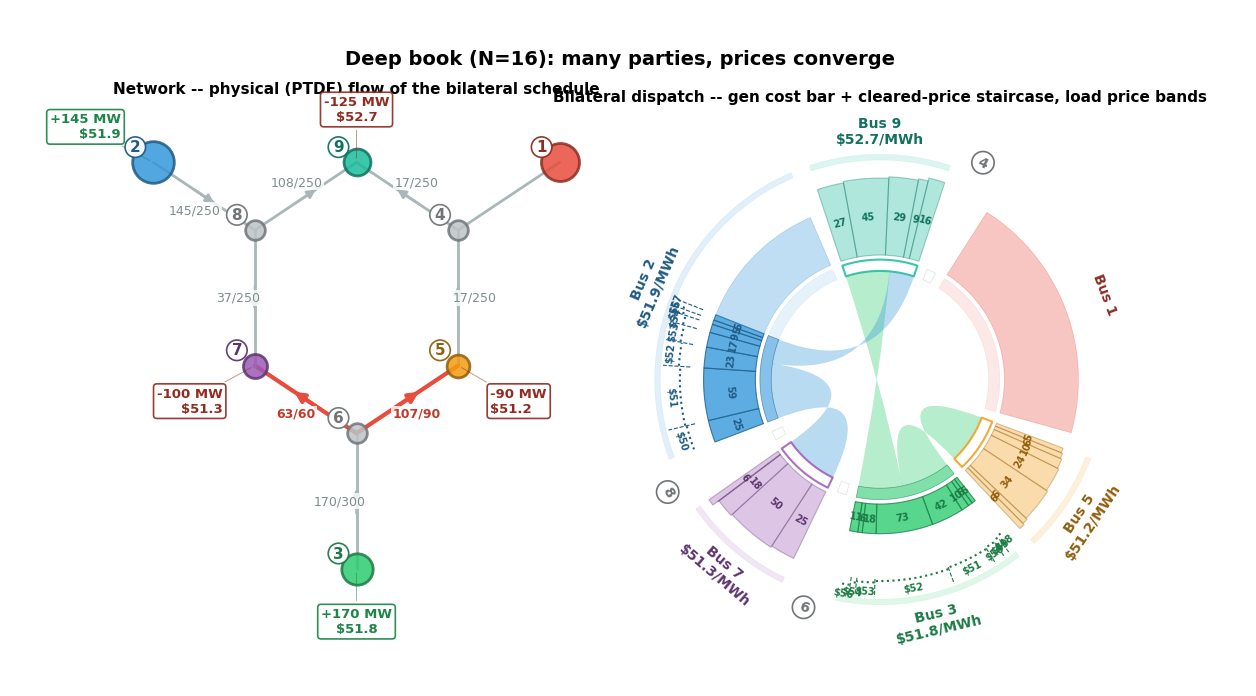

In [9]:
bilateral_dispatch_figure(clear(N=1),  suppliers, 'Thin book (N=1): few parties, dispersed prices')
bilateral_dispatch_figure(clear(N=16), suppliers, 'Deep book (N=16): many parties, prices converge')

## 4. Lever: risk aversion and the price-risk distribution

The second and third forces set the **premium** itself. Committing ahead of an uncertain
spot price is a forward contract, and Bessembinder-Lemmon (2002) show its price carries a
premium fixed by **both sides** hedging that price: the **load's aversion** $\gamma$ (it
bids above expected cost to be served firmly) and the **seller's appetite** $\alpha$ (it
asks above cost for the upside), each scaled by the **width of the price-risk distribution**
$\sigma$ (`PRICE_RISK`). Raise any of them and the premium rises; with $\sigma=0$ there is no
risk to price in the offers, the premium falls away, and the discriminatory midpoint can even
hand the load part of the bargaining surplus (a negative premium). The load still procures its
**full** volume throughout -- risk changes the **price**, not the quantity.

,served (MW),premium $/MWh
load_aversion,,
0.0,312.0,0.9
0.5,315.0,3.5
1.0,315.0,5.4
1.5,315.0,7.0
2.0,315.0,8.0
3.0,315.0,10.7


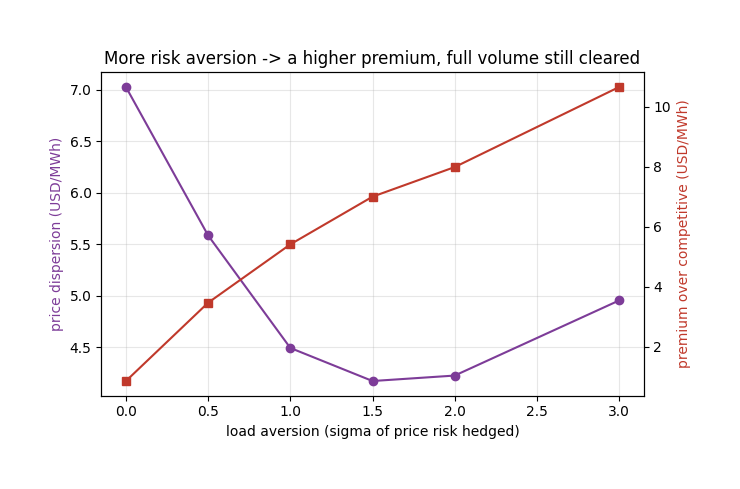

In [10]:
rows = []
for la in (0.0, 0.5, 1.0, 1.5, 2.0, 3.0):
    rs = [clear(belief_=belief(load_aversion=la), seed=s) for s in range(20)]
    ms = [metrics(r) for r in rs]
    rows.append({'load_aversion': la, 'dispersion': np.mean([m[0] for m in ms]),
                 'premium': np.mean([m[1] for m in ms]),
                 'served': np.mean([sum(r.cleared.values()) for r in rs])})
rk = pd.DataFrame(rows)
display(rk.assign(**{'served (MW)': rk['served'].round(0), 'premium $/MWh': rk['premium'].round(1)})
          [['load_aversion', 'served (MW)', 'premium $/MWh']].set_index('load_aversion'))
lever_figure(rk, 'load_aversion', 'load aversion (sigma of price risk hedged)',
             'More risk aversion -> a higher premium, full volume still cleared')

Risk-neutral and risk-averse procurement of the **same full forecast**, side by side --
the difference is the price the load pays, not the quantity it gets:

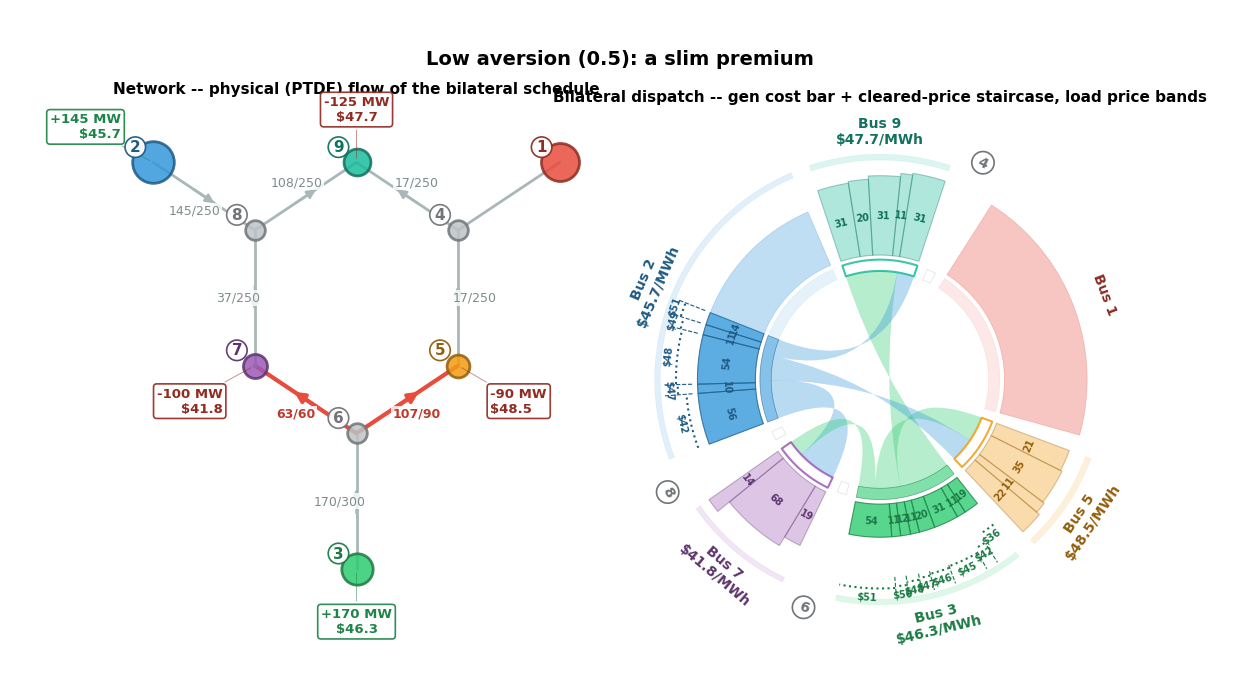

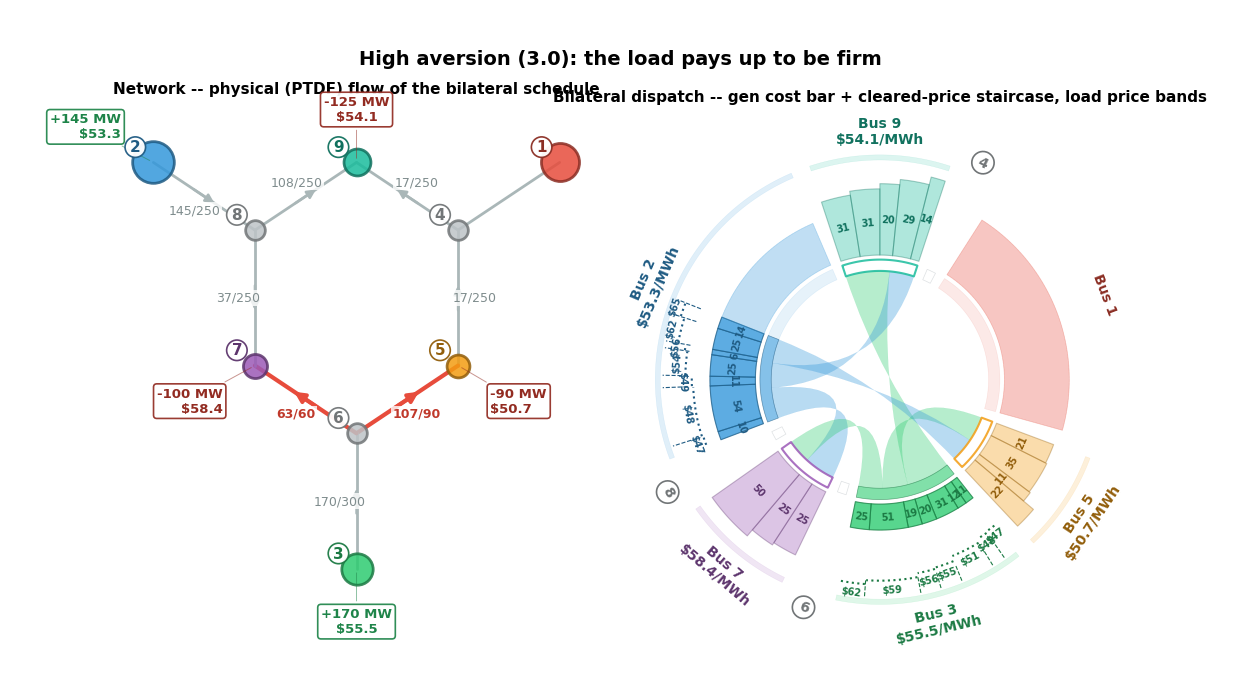

In [11]:
bilateral_dispatch_figure(clear(belief_=belief(load_aversion=0.5)), suppliers,
    'Low aversion (0.5): a slim premium')
bilateral_dispatch_figure(clear(belief_=belief(load_aversion=3.0)), suppliers,
    'High aversion (3.0): the load pays up to be firm')

,price dispersion $/MWh,premium $/MWh
price_risk,,
0.0,3.1,-13.8
10.0,2.7,-0.8
20.0,4.2,7.0
30.0,5.7,14.7
40.0,7.4,21.8


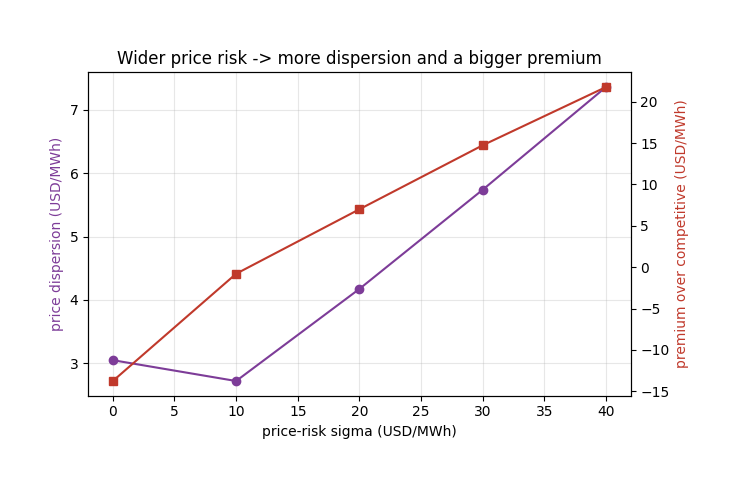

In [12]:
# the price-risk width sigma scales the same premium (sellers and loads both price it in)
rows = []
for sg in (0.0, 10.0, 20.0, 30.0, 40.0):
    ms = [metrics(clear(belief_=belief(price_risk=sg), seed=s)) for s in range(20)]
    rows.append({'price_risk': sg, 'dispersion': np.mean([m[0] for m in ms]),
                 'premium': np.mean([m[1] for m in ms])})
sig = pd.DataFrame(rows)
display(sig.assign(**{'price dispersion $/MWh': sig['dispersion'].round(1),
                      'premium $/MWh': sig['premium'].round(1)})
           [['price_risk', 'price dispersion $/MWh', 'premium $/MWh']].set_index('price_risk'))
lever_figure(sig, 'price_risk', 'price-risk sigma (USD/MWh)',
             'Wider price risk -> more dispersion and a bigger premium')

## 5. Real-time balancing: a schedule feasible by right, infeasible on the grid

The pre-schedule is feasible **contract by contract** -- every delivery $A_{n\to k}$ respects
its own transmission right's ATC. But the rights are rated path-by-path, blind to one
another, so the awarded set can **overload** a line once the flows superpose (the
simultaneous-feasibility failure of notebook 111). Real time must therefore **balance** the
bilateral pre-schedule: a minimum-cost **counter-trade** curtails the schedule loading the
constrained line and ramps a feasible substitute, with the production-cost uplift charged to
the **curtailed schedule** (causer-pays). This is the bilateral analogue of the redispatch a
central market would have done inside its clearing.

The figure below is the **standard transmission-rights view** used across the series. Each
arc is a point-to-point right from a generator bus to a load center, labelled by its **path**;
the scheduled **MW and the path's ATC sit in the table** beside the graph. The physical
*superposed* flow rides on the lines -- a direction arrow and `flow / limit` (the share of
capacity) -- and any line the rights **overload turns red** (the simultaneous-feasibility test
failing): *feasible by right, infeasible on the grid*. Later notebooks layer the same picture
with parallel-flow attribution and the inter-BA transfer cutset.

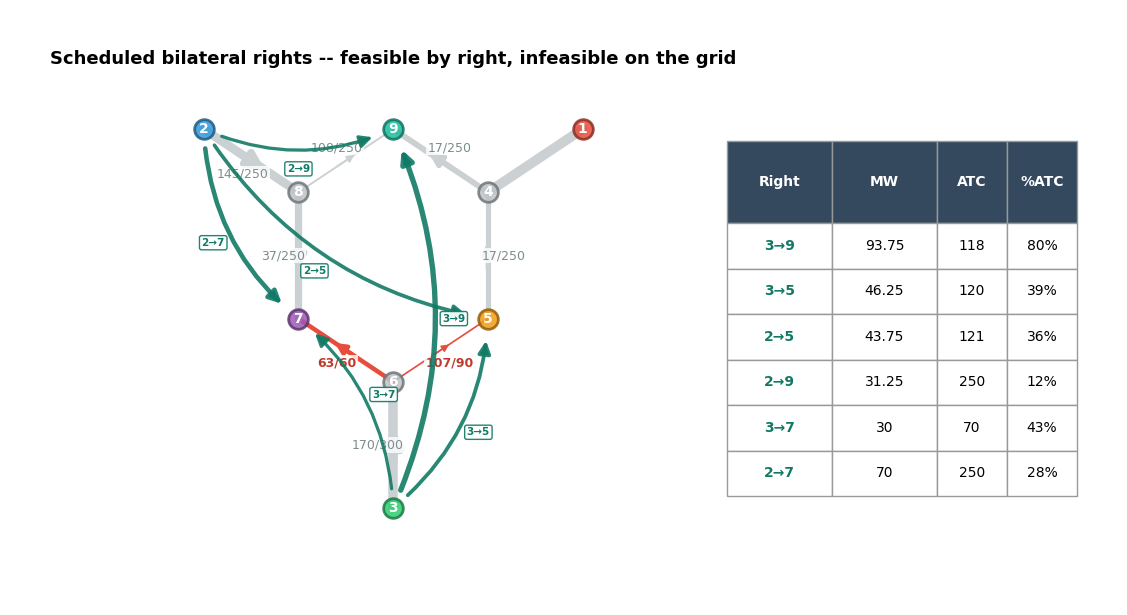

In [13]:
# The standard transmission-rights view (layers 0-1-2): arcs are point-to-point rights
# (generator bus -> load center) labelled by path, with MW / ATC in the table at right; the
# lines carry the superposed flow (direction + share of capacity), red where the rights
# overload it (the SFT failure that balancing fixes).
rights = [{'source': a.source, 'sink': a.sink, 'mw': a.mw} for a in da.awards]
figs.rights_figure(build_network(line_ratings=RATINGS), pt, rights,
                   show_atc=True, show_sft=True,
                   title='Scheduled bilateral rights -- feasible by right, infeasible on the grid')
plt.show()

In [14]:
feas, before = bl.power_flow_check(pt, da.awards)
print(f'pre-schedule simultaneously feasible? {feas}')
display(before[before['loading_%'] >= 80] if (before['loading_%'] >= 80).any() else before)
rd = bl.order_book_redispatch(pt, suppliers, da, voll=VOLL)
print(f'feasible before = {rd.feasible_before}  ->  after = {rd.feasible_after}')
print('curtail (causing schedule):', {g: round(v, 1) for g, v in rd.down.items()})
print('ramp up (substitute)      :', {g: round(v, 1) for g, v in rd.up.items()})
bal = rd.redispatch_cost / max(1.0, sum(da.cleared.values()))
print(f'balancing uplift = ${rd.redispatch_cost:.0f}  (= ${bal:.2f}/MWh) charged causer-pays:',
      {g: round(v) for g, v in rd.charge_by_arb.items()})

pre-schedule simultaneously feasible? False

,from,to,flow,limit,loading_%,overload
line,,,,,,
line_2,5,6,-106.8,90.0,119.0,True
line_4,6,7,63.2,60.0,105.0,True


feasible before = False  ->  after = True

curtail (causing schedule):

{'gen_1': 27.3}

ramp up (substitute)      :

{'gen_slack_0': 27.3}

balancing uplift = $820  (= $2.60/MWh) charged causer-pays:

{'gen_1': 820}

## 6. Sandbox

Turn the knobs in the configuration cell at the top and re-run, or edit the copy below.
Raise `S_LOAD_AVERSION` / `S_GEN_APPETITE` / `S_PRICE_RISK` to widen the premium; raise
`S_N` to deepen the book and tighten the spread; tighten a line in `S_RATINGS` until the
balancing uplift grows; change `S_SEED` to draw a different interval. Generator marginal
costs stay fixed throughout.

procured 315 of 315 MW | avg premium $+7.7/MWh | spread $17.0 | balancing uplift $0 (feasible after True)

,procured (MW),competitive $/MWh,price paid $/MWh,premium $/MWh
5,90.0,55.6,49.2,-6.4
7,100.0,30.6,51.6,21.0
9,125.0,44.8,53.4,8.6


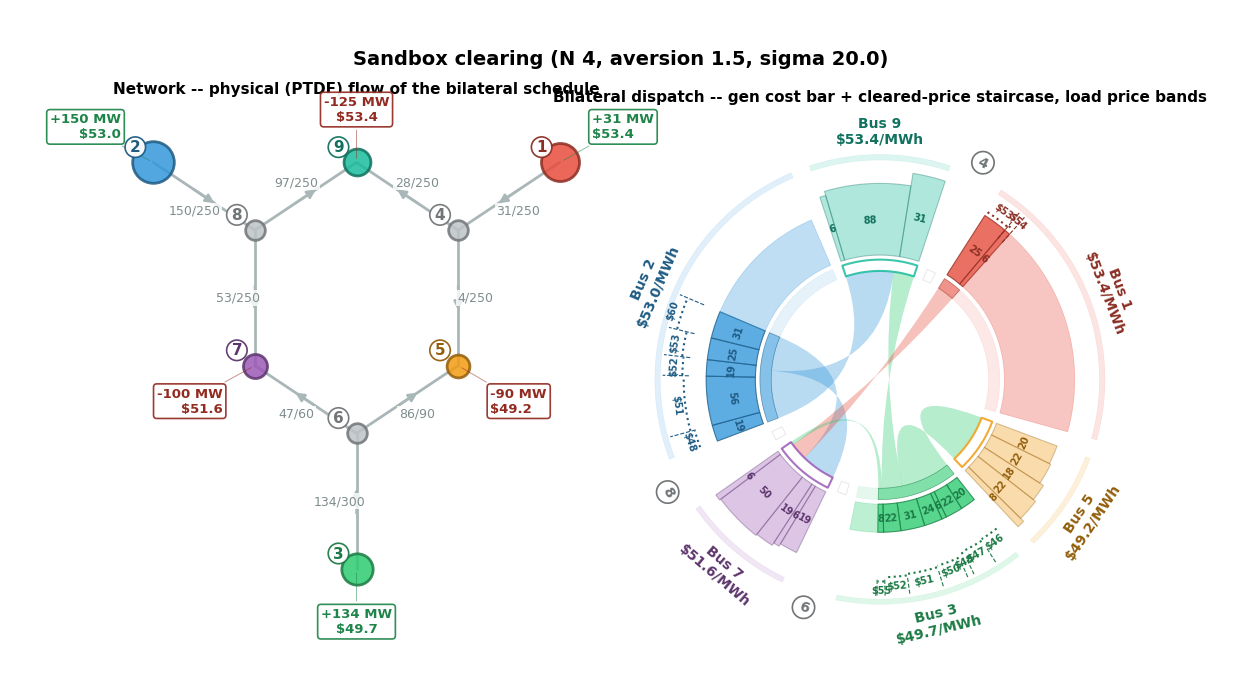

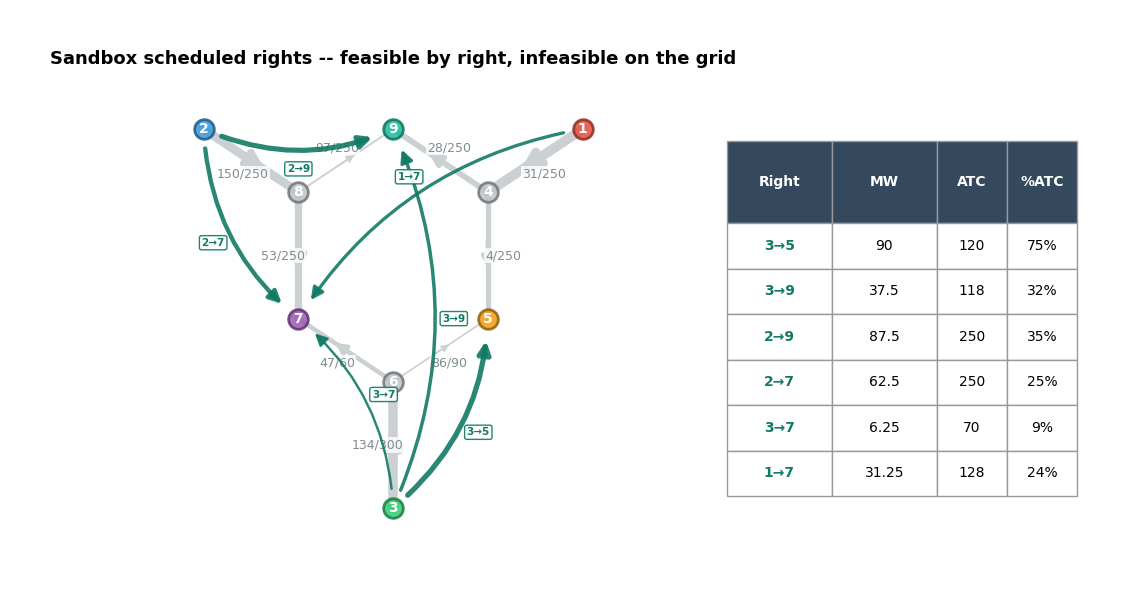

In [15]:
# =========================  SANDBOX -- EDIT HERE  =========================
S_RATINGS       = {'line_4': 60.0, 'line_2': 90.0}  # line limits (MW)
S_N             = 4                                 # number of parties (liquidity)
S_PRICE_RISK    = 20.0                              # perceived price-risk sigma ($/MWh)
S_GEN_APPETITE  = 1.0                               # seller appetite for the upside
S_LOAD_AVERSION = 1.5                               # load aversion (forward premium)
S_K             = 0.5                               # price split (0.5 midpoint / 0 lift ask / 1 take bid)
S_SEED          = 11                                # the interval draw
# =========================================================================
spt  = shift_factors(build_network(line_ratings=S_RATINGS))
slcs = bl.calibrate_load_centers(spt, voll=VOLL, firmness=FIRMNESS)
sbel = bl.Belief(price_risk=S_PRICE_RISK, gen_appetite=S_GEN_APPETITE, load_aversion=S_LOAD_AVERSION)
sda  = bl.double_auction_clear(spt, suppliers, slcs, belief=sbel, k=S_K,
                               rng=np.random.default_rng(S_SEED), thickness=S_N, network='rights')
srd  = bl.order_book_redispatch(spt, suppliers, sda, voll=VOLL)
served, fc = sum(sda.cleared.values()), sum(slcs[k].d_nom for k in slcs)
print(f'procured {served:.0f} of {fc:.0f} MW | avg premium '
      f"${np.nanmean([v for v in sda.premium.values() if v==v]):+.1f}/MWh | spread ${sda.shade_wedge:.1f} | "
      f'balancing uplift ${srd.redispatch_cost:.0f} (feasible after {srd.feasible_after})')
display(pd.DataFrame({
    'procured (MW)':     {k: round(sda.cleared[k], 0) for k in sda.cleared},
    'competitive $/MWh': {k: round(slcs[k].p_comp, 1) for k in sda.cleared},
    'price paid $/MWh':  {k: round(sda.price[k], 1) for k in sda.cleared},
    'premium $/MWh':     {k: round(sda.premium[k], 1) for k in sda.cleared}}))
bilateral_dispatch_figure(sda, suppliers,
    f'Sandbox clearing (N {S_N}, aversion {S_LOAD_AVERSION}, sigma {S_PRICE_RISK})',
    pt_=spt, line_ratings=S_RATINGS)

# the standard transmission-rights view for the sandbox clearing
srights = [{'source': a.source, 'sink': a.sink, 'mw': a.mw} for a in sda.awards]
figs.rights_figure(build_network(line_ratings=S_RATINGS), spt, srights,
                   show_atc=True, show_sft=True,
                   title='Sandbox scheduled rights -- feasible by right, infeasible on the grid')
plt.show()